In [1]:
source(here::here("R/01_init.R"))

✔ Constants initialized successfully

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


here() starts at /home/sand94/projects/VReGTrET/GraphTheory_ET_VR_Westbrueck/Analysis/raw_gaze_analysis

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emme

In [2]:
df <- read_csv(here(config$DATA_FOLDER, config$SCOTOMA_DATA_FILE))
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
df_node <- read_csv(here(config$DATA_FOLDER, config$SCOTOMA_NODE_FILE))

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        duration = clusterDuration
    ) |>
    group_by(PID, group, hitObjectColliderName, building_location) |>
    summarize(
        mean_connections = mean(connections)
    ) |>
    ungroup() |>
    filter(mean_connections > 0)

Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'PID', 'group', 'hitObjectColliderName'.
You can override using the `.groups` argument.


### Modeling

In [4]:
df <- df %>% 
    mutate(
        group = factor(group, levels = c("control", "peripheral", "central"))
    )

models <- fit_model_sequence(df, median_clusterDuration)
model_0 <- models$null
model_inter <- models$intermediate
model_full <- models$full

ℹ Fitting null model: median_clusterDuration ~ 1 + (1 | PID) + (1 | hitObjectColliderName)

ℹ Fitting intermediate model: median_clusterDuration ~ 1 + building_location + (1 | PID) +  and     (1 | hitObjectColliderName)

ℹ Fitting full model: median_clusterDuration ~ 1 + building_location + group + (1 |  and     PID) + (1 | hitObjectColliderName)



In [5]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, levels = c("control", "peripheral", "central"))
    )

node_models <- fit_poisson_sequence(df_node, mean_connections)
node_model_0 <- node_models$null
node_model_inter <- node_models$intermediate
node_model_full <- node_models$full
     

ℹ Fitting null model: mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName)

ℹ Fitting intermediate model: mean_connections ~ 1 + building_location + (1 | PID) + (1 | hitObjectColliderName)

ℹ Fitting full model: mean_connections ~ 1 + building_location + group + (1 | PID) +  and     (1 | hitObjectColliderName)



In [6]:
lrt_dwell_models <- compare_models(models) 
lrt_node_models <- compare_models(node_models)

ℹ Performing LRT comparisons...



ℹ Performing LRT comparisons...



In [7]:
lrt_dwell_models %>% tidy()

comparison,chi.squared,p.value,p_string
<chr>,<dbl>,<dbl>,<chr>
null vs intermediate,13.49,2e-04,$p$ < .001***
intermediate vs full,14.99,6e-04,$p$ < .001***


In [8]:
lrt_node_models %>% tidy()

comparison,chi.squared,p.value,p_string
<chr>,<dbl>,<dbl>,<chr>
null vs intermediate,66.55,0.0000,$p$ < .001***
intermediate vs full,2.96,0.2273,$p$ = 0.227


#### EMM Node and Dwell Time

In [9]:
emm_group_dwell_model_full <- model_full %>% extract_emmeans(~ group)
contrasts_group_dwell_model_full <- emm_group_dwell_model_full %>% extract_contrasts()

emm_group_dwell_model_full
contrasts_group_dwell_model_full

emm_region_dwell_model_full <- model_full %>% extract_emmeans(~ building_location)
contrasts_region_dwell_model_full <- emm_region_dwell_model_full %>% extract_contrasts()

emm_region_dwell_model_full
contrasts_region_dwell_model_full


 group      response     SE  df asymp.LCL asymp.UCL
 control       0.433 0.0169 Inf     0.400     0.466
 peripheral    0.498 0.0231 Inf     0.453     0.544
 central       0.400 0.0140 Inf     0.373     0.428

Results are averaged over the levels of: building_location 
Confidence level used: 0.95 

contrast,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
control - peripheral,-0.06511405,0.02161389,Inf,-0.115770544,-0.01445755,-3.012601,7.306395e-03
control - central,0.03268118,0.01657162,Inf,-0.006157728,0.07152008,1.972118,1.191344e-01
peripheral - central,0.09779523,0.02104862,Inf,0.048463552,0.14712690,4.646158,1.009053e-05


 building_location response     SE  df asymp.LCL asymp.UCL
 outside              0.409 0.0127 Inf     0.384     0.434
 inside               0.479 0.0217 Inf     0.437     0.521

Results are averaged over the levels of: group 
Confidence level used: 0.95 

contrast,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
outside - inside,-0.07000843,0.02073761,Inf,-0.1106534,-0.02936346,-3.375916,0.0007357048


#### Figure Generation

In [10]:
model_full_emm <- fit_model_full(df, median_clusterDuration, group_levels = c("central", "control", "peripheral"))

emm_table_pairs <- contrasts_group_dwell_model_full
custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("control", "control", "peripheral"),
        group2 = c("peripheral", "central", "central"),
        label = c("**", "P = 0.11", "***"),
        y.position = c(0.80, 0.75, 0.85)
    )

dwell_time_fig <- plot_dwell_time(model_full_emm, df, custom_emm_table)

ℹ Fitting full model: median_clusterDuration ~ 1 + building_location + group + (1 |  and     PID) + (1 | hitObjectColliderName)



In [11]:
node_model_full_emm <- fit_model_full(df_node, mean_connections, family = poisson(), group_levels = c("central", "control", "peripheral"))
ndc_mean_fig <- plot_ndc(node_model_full_emm, df_node)

ℹ Fitting full model: mean_connections ~ 1 + building_location + group + (1 | PID) +  and     (1 | hitObjectColliderName)



Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


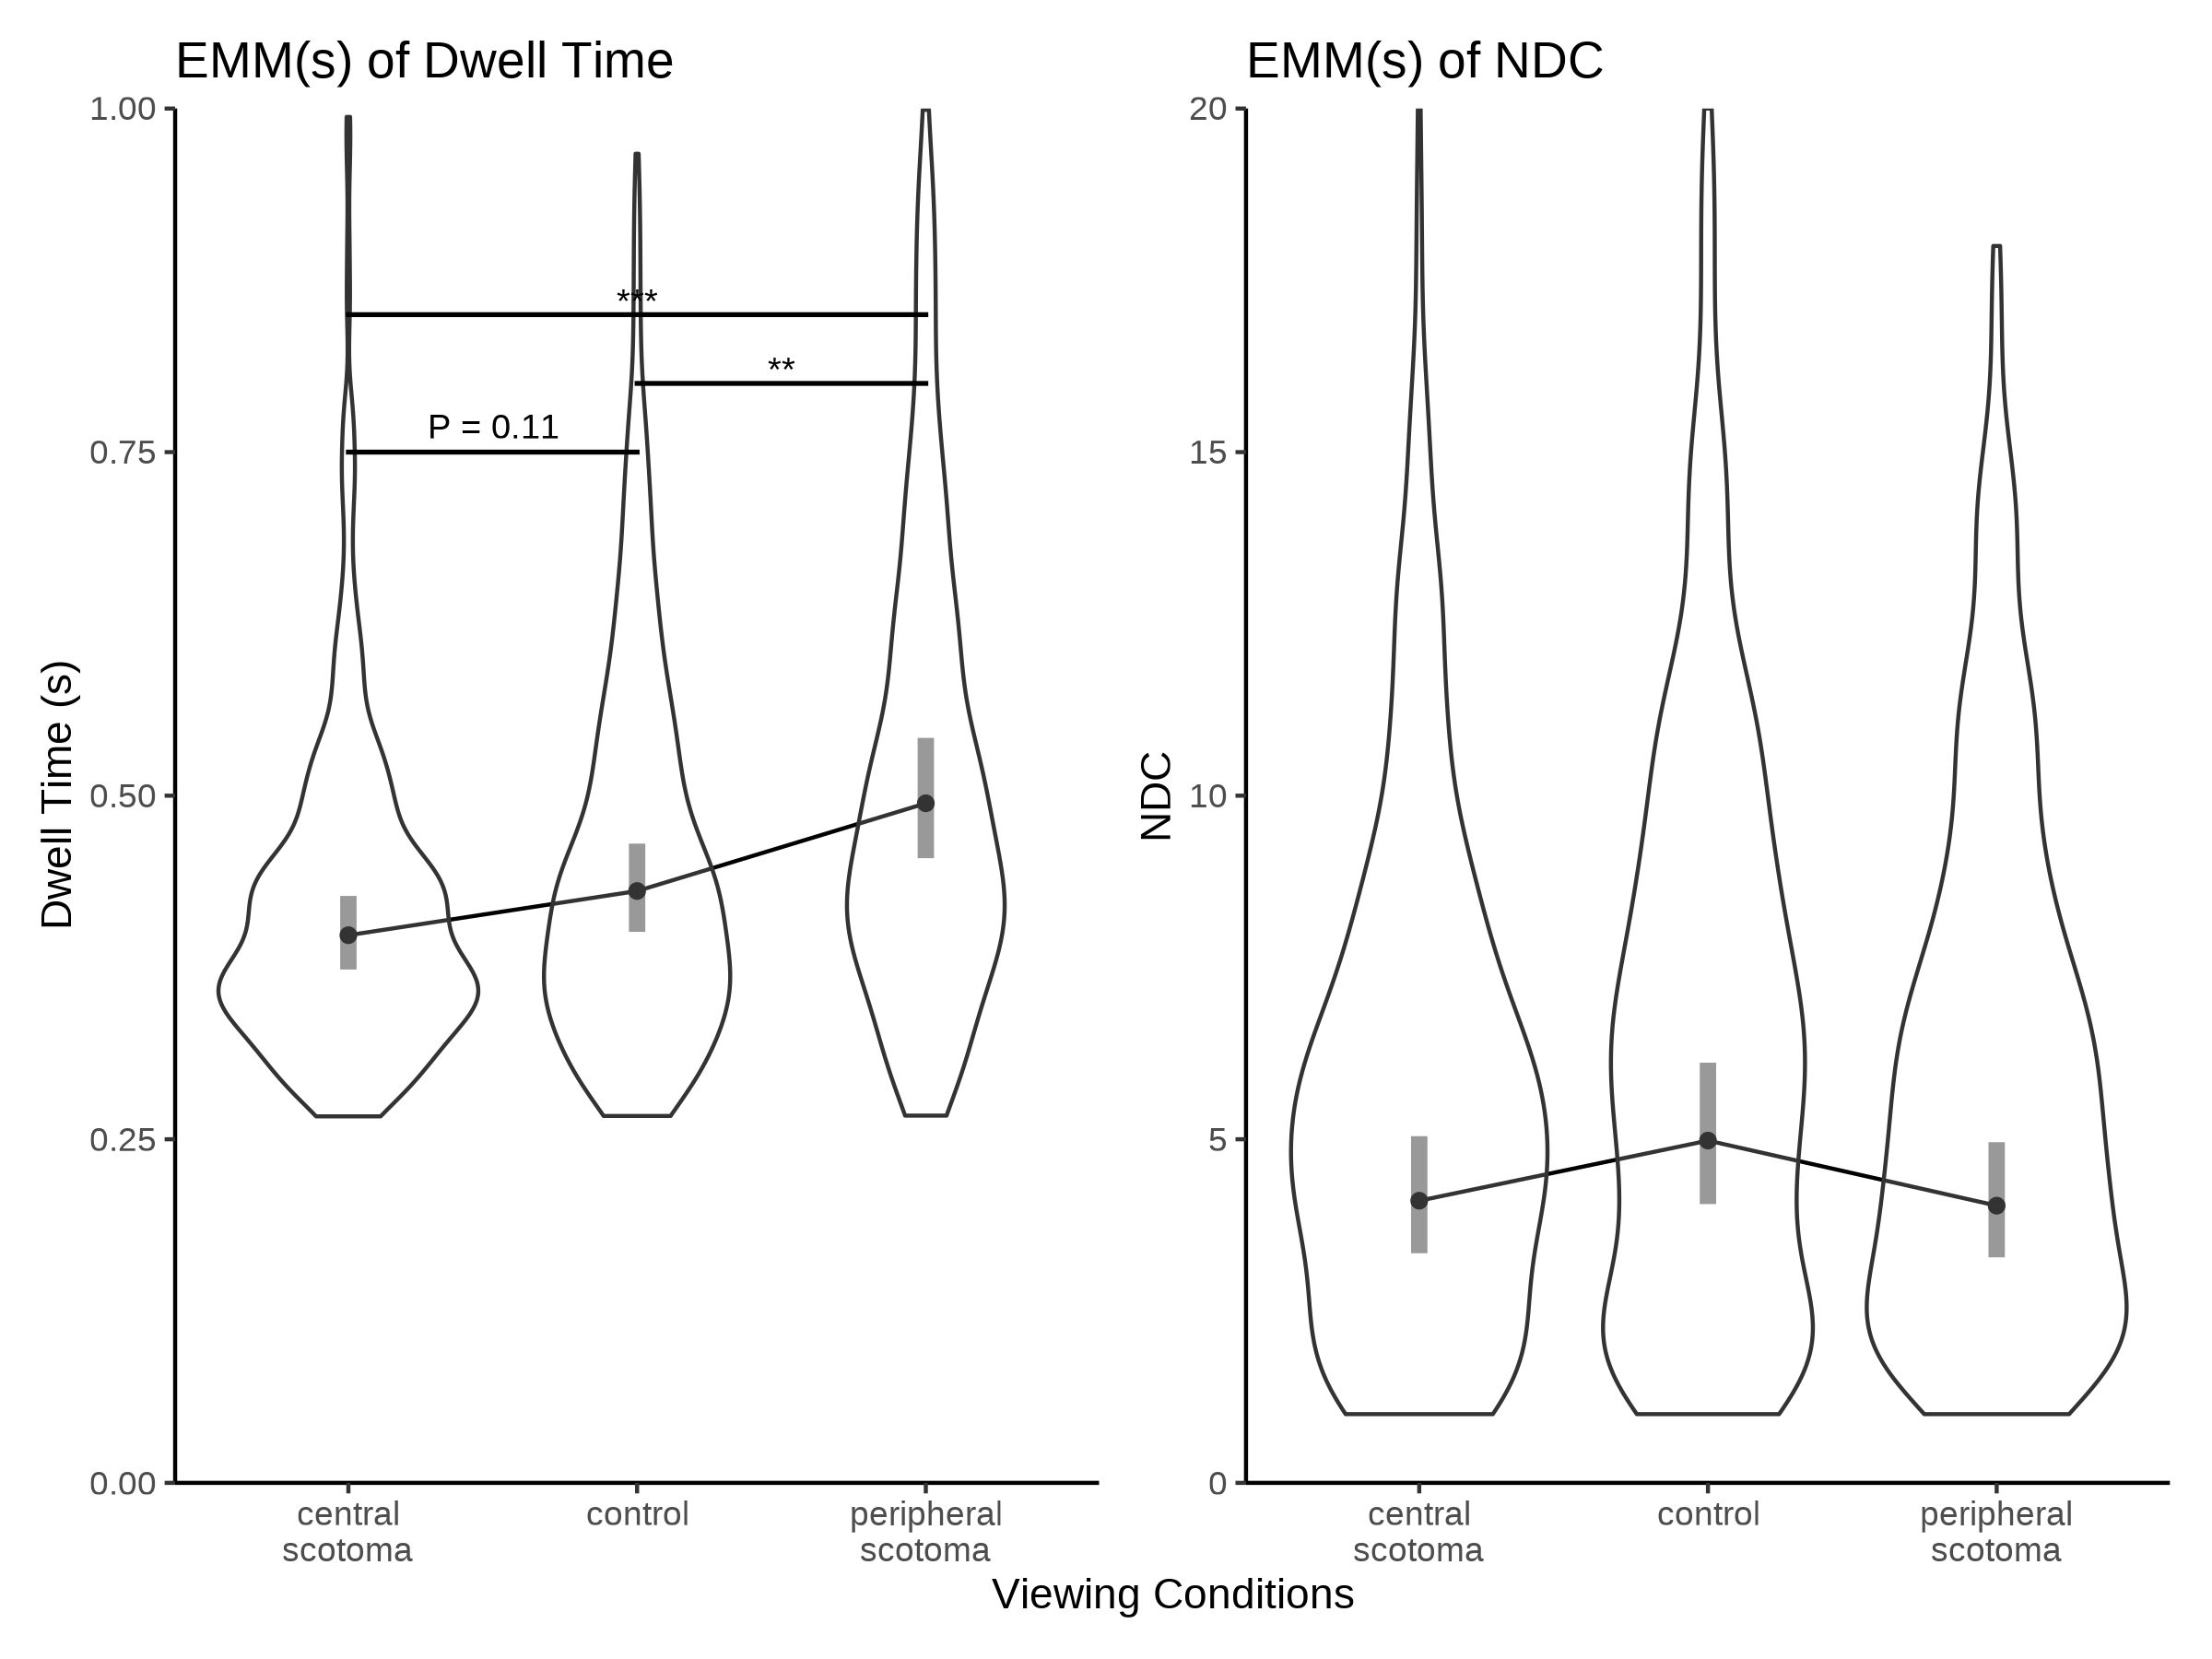

In [12]:
combine_dwell_ndc_plots(dwell_plot = dwell_time_fig, ndc_plot = ndc_mean_fig)


In [13]:
emm_region_dwell_model_full <- model_full %>% extract_emmeans(~ building_location)
dwell_model_full_contrasts_region <- emm_region_dwell_model_full %>% extract_contrasts()

emm_region_ndc_model_full <- node_model_full %>% extract_emmeans(~ building_location)
ndc_model_full_contrasts_region <- emm_region_ndc_model_full %>% extract_contrasts()

dwell_contrast_table <- format_contrast_table(dwell_model_full_contrasts_region,y_positions = c(0.75),sig_labels = c("***"))
ndc_contrast_table <- format_contrast_table(ndc_model_full_contrasts_region, y_positions = c(15), sig_labels = c("***"))


In [14]:
dwell_time_location_fig <- plot_dwell_time_by_location(model_full_emm, df, contrast_table = dwell_contrast_table)
ndc_location_fig <- plot_ndc_by_location(node_model_full_emm, df_node, contrast_table = ndc_contrast_table)
combined_location_fig <- combine_dwell_ndc_plots_by_location(dwell_time_location_fig, ndc_location_fig)


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


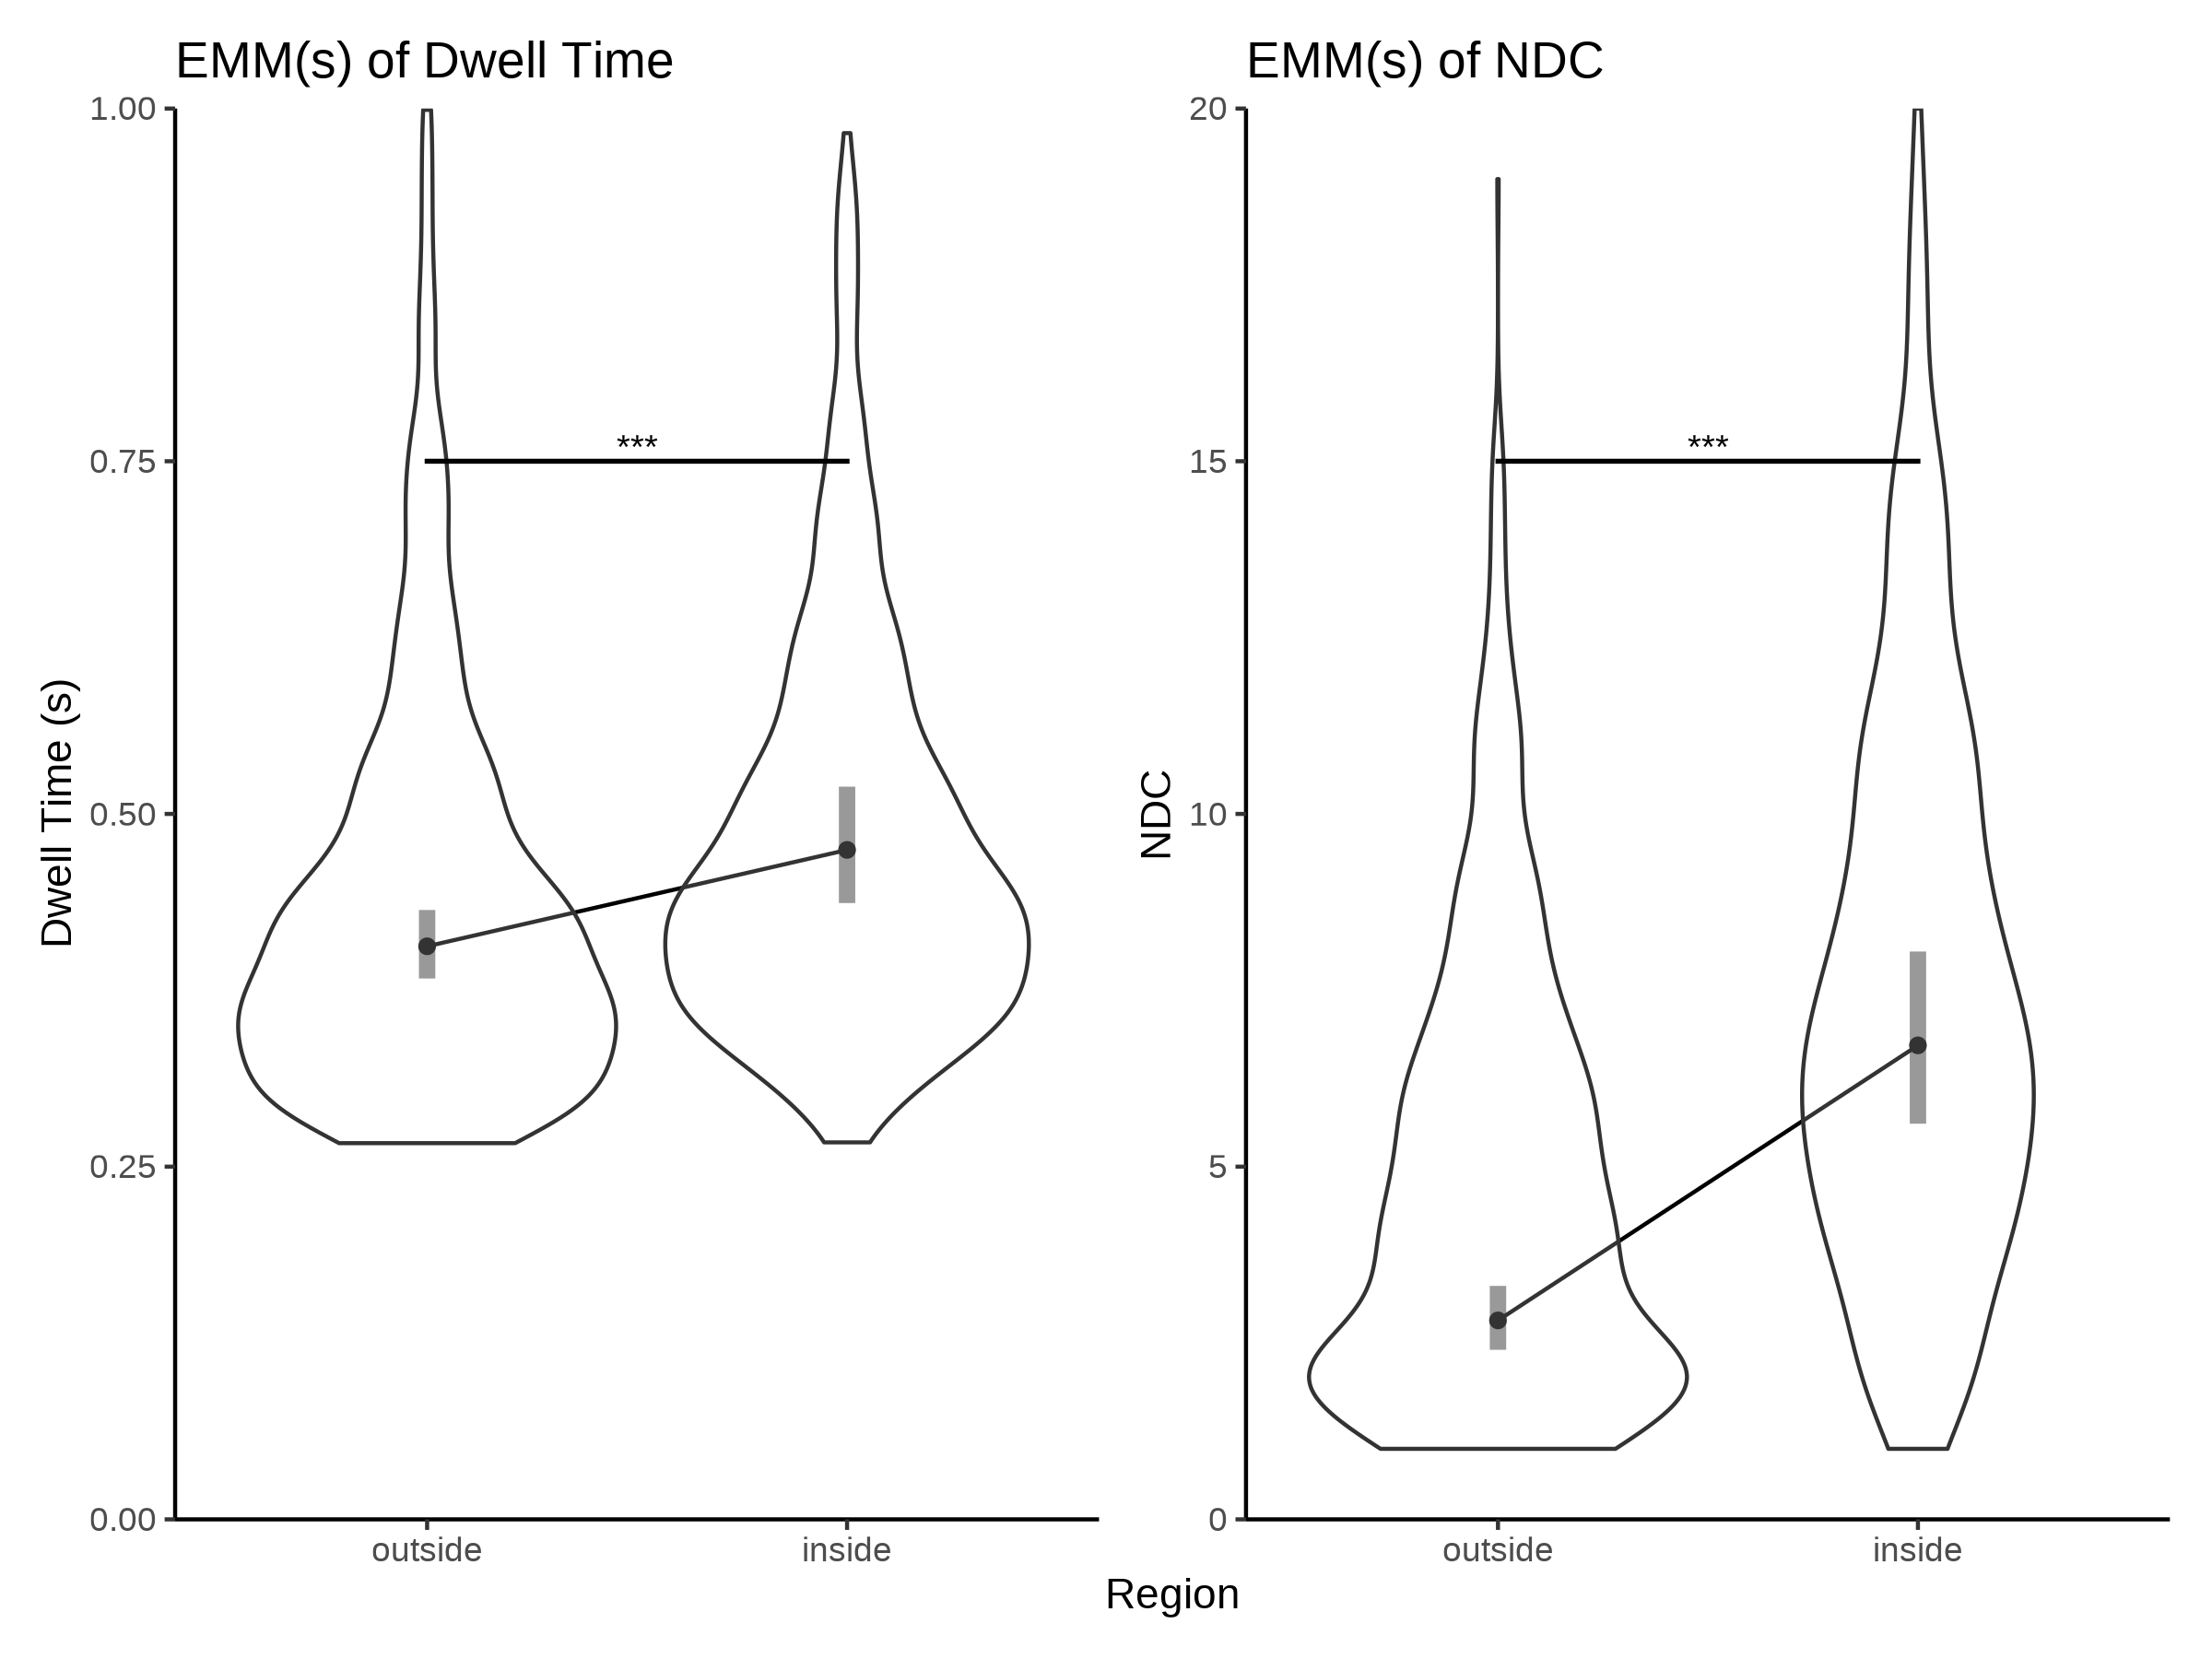

In [15]:
combined_location_fig

#### Model Summary

In [16]:
dwell_time_model_summaries <- get_sim_model_summary(model_0, model_inter, model_full)
node_model_summaries <- get_sim_model_summary(node_model_0, node_model_inter, node_model_full)

#### GT Table Generation

In [17]:
source(here("R", "06_tables.R"))

In [18]:
dt <- build_model_summary_table(dwell_summaries = dwell_time_model_summaries, node_summaries = node_model_summaries)
export_model_summary_table(dt,output_path = here(config$OUTPUT_FOLDER, "refactored_summary.html"))

In [19]:
emm_dwell <- extract_emmeans(model_full, ~ group)
emm_dwell_region <- extract_emmeans(model_full, ~ building_location)
contrasts_dwell <- extract_contrasts(emm_dwell)
constrasts_dwell_region <- extract_contrasts(emm_dwell_region)

emm_ndc <- extract_emmeans(node_model_full, ~ group)
emm_ndc_region <- extract_emmeans(node_model_full, ~ building_location)
contrasts_ndc <- extract_contrasts(emm_ndc)
constrats_ndc_region <- extract_contrasts(emm_ndc_region)


In [20]:
posthoc_group <- build_posthoc_table(
     emm_dwell, contrasts_dwell,
     emm_ndc, contrasts_ndc,
     "group",
     TRUE,
     relabel_groups = c("peripheral" = "peripheral scotoma", "central" = "central scotoma")
)

posthoc_loc <- build_posthoc_table(
    emm_dwell_region, constrasts_dwell_region,
    emm_ndc_region, constrats_ndc_region,
    "building_location"
)

In [21]:
export_posthoc_table(posthoc_group, here(config$OUTPUT_FOLDER, config$POSTHOC_COMBINED_HTML), "group",
                     combined_table = posthoc_loc, combined_factor_name = "building_location")  